<a href="https://colab.research.google.com/github/ivan-block/Traffic-signs-classification/blob/main/traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers, models
from keras.preprocessing import image
import numpy as np

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import zipfile
import os

zip_path = "traffic.zip"
extract_path = "traffic_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)
print("Folders:", os.listdir(extract_path))

Extracted to: traffic_data
Folders: ['traffic']


In [28]:
img_size = (224, 224)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "traffic_data/traffic",                # path to your folder
    validation_split=0.2,     # 20% validation
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "traffic_data/traffic",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.


In [29]:
train_data = train_data.map(lambda x, y: (x / 255.0, y))
val_data = val_data.map(lambda x, y: (x / 255.0, y))

In [30]:
traffic = tf.keras.preprocessing.image_dataset_from_directory(
    'traffic_data/traffic',
    image_size=img_size,
    batch_size=batch_size
)

class_names = traffic.class_names
print("Classes:", class_names)

Found 200 files belonging to 2 classes.
Classes: ['Green', 'Red']


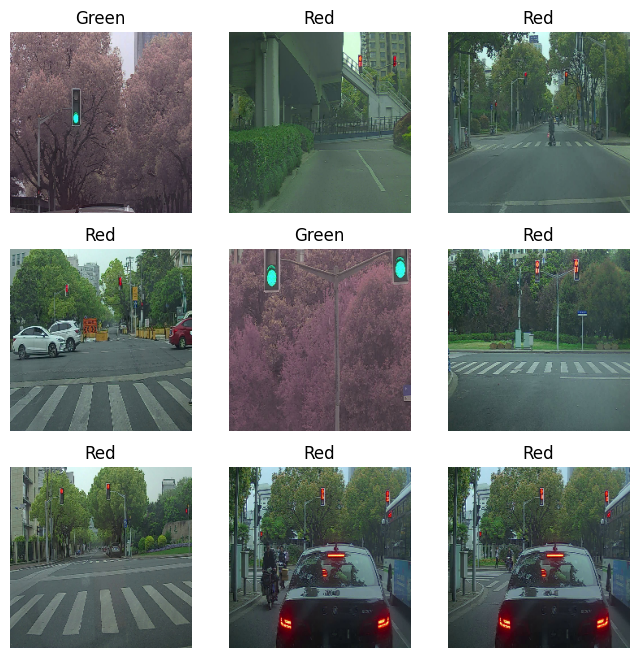

In [31]:
plt.figure(figsize=(8, 8))

for images, labels in traffic.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [32]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.5875 - loss: 1.4645 - val_accuracy: 0.5000 - val_loss: 0.6897
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.5250 - loss: 0.7086 - val_accuracy: 0.5000 - val_loss: 0.6889
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 7s/step - accuracy: 0.5437 - loss: 0.6864 - val_accuracy: 0.5000 - val_loss: 0.6857
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 7s/step - accuracy: 0.5125 - loss: 0.6952 - val_accuracy: 0.5000 - val_loss: 0.6877
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 7s/step - accuracy: 0.5250 - loss: 0.6808 - val_accuracy: 0.7000 - val_loss: 0.6757
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - accuracy: 0.6375 - loss: 0.6575 - val_accuracy: 0.5000 - val_loss: 0.6633
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.6187 - loss: 0.6261 - val_accuracy: 0.4750 - val_loss: 0.6666
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.6438 - loss: 0.6206 - val_accuracy: 0.6250 - val_loss: 0.6276
Epoch 9/

In [35]:
model.evaluate(val_data)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step - accuracy: 0.6750 - loss: 0.6710


[0.6710182428359985, 0.675000011920929]

In [38]:
img = image.load_img("traffic_data/traffic/Red/000171.jpg", target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Red sign")
else:
    print("Green sign")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Green sign


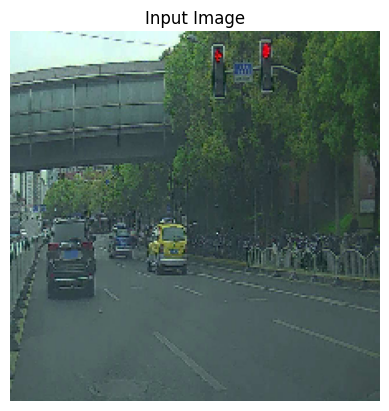

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Prediction: Green sign


In [39]:
img = image.load_img("traffic_data/traffic/Red/000171.jpg", target_size=(224,224))

plt.imshow(img)
plt.axis('off')  # Hide axes
plt.title("Input Image")
plt.show()

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Prediction: Red sign")
else:
    print("Prediction: Green sign")

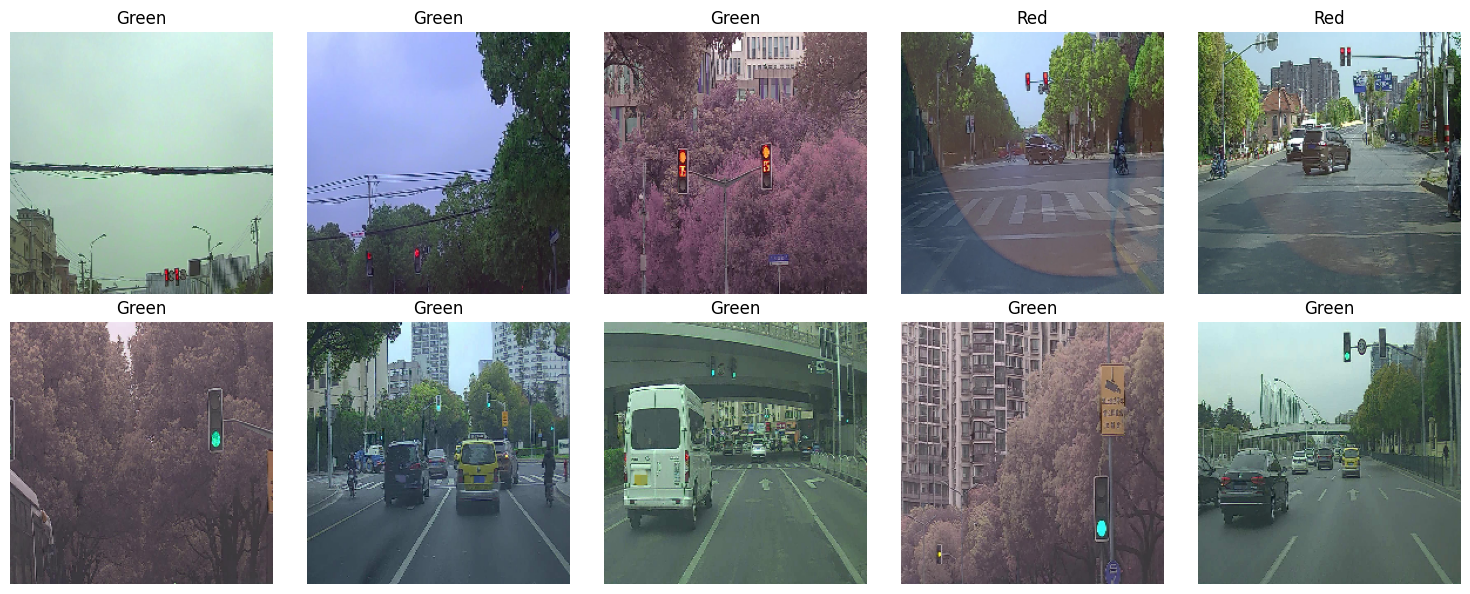

In [43]:
folder_path = "traffic_data/traffic"

image_paths = []
for label in ["Red", "Green"]:
    class_folder = os.path.join(folder_path, label)
    for file in os.listdir(class_folder)[:5]:  # take 5 from each class
        image_paths.append(os.path.join(class_folder, file))

cols = 5
rows = int(np.ceil(len(image_paths) / cols))

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(image_paths):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array_exp, verbose=0)
    label = "Red" if prediction[0] > 0.5 else "Green"

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(label)

plt.tight_layout()
plt.show()

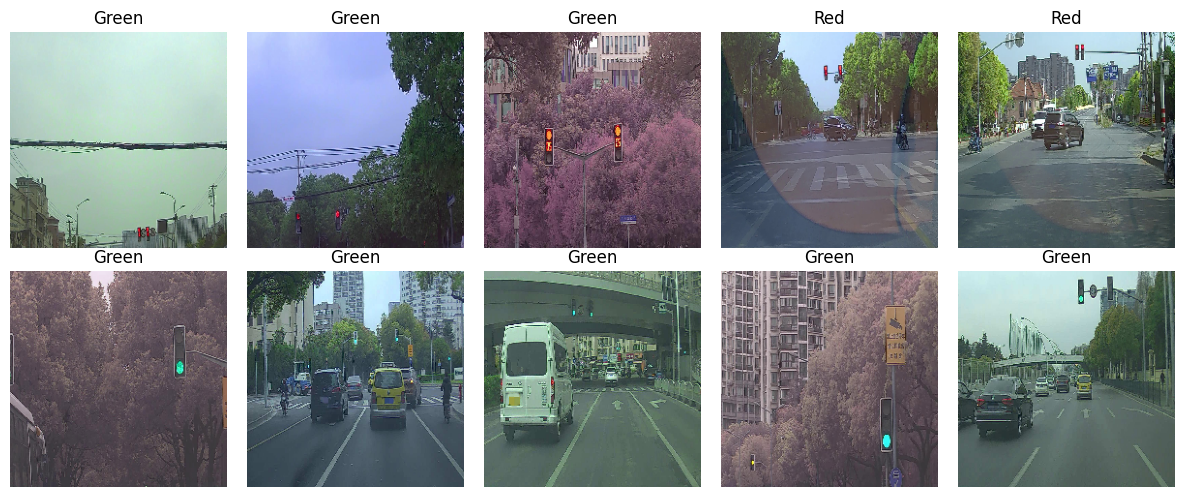

In [42]:
paths = [
    os.path.join("traffic_data/traffic", cls, f)
    for cls in ["Red", "Green"]
    for f in os.listdir(f"traffic_data/traffic/{cls}")[:5]
]

plt.figure(figsize=(12, 5))

for i, p in enumerate(paths):
    img = image.load_img(p, target_size=(224,224))
    arr = np.expand_dims(image.img_to_array(img)/255.0, 0)
    pred = model.predict(arr, verbose=0)[0]
    label = "Red" if pred > 0.5 else "Green"

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()